In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [3]:
X,y = make_classification(n_features=5, n_redundant= 0, n_informative = 5, n_clusters_per_class = 1)

 ### n_features=5
 - total number of input features (columns) in X.

- So each data point looks like:

- [x1, x2, x3, x4, x5]

### n_redundant=0
- Redundant features are:
  - Linear combinations of informative features
  - Do not add new information

### n_informative=5
- Informative features:
    - Actually help in class separation
    - Affect the class label directly

### n_clusters_per_class=1
- Each class forms one compact cluster
- Classes are well separated
- If this value were higher: Decision boundary becomes more complex


In [4]:
df = pd.DataFrame(X, columns = ['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.712748,1.712261,-0.846562,-0.299946,0.188802,1
1,2.133705,-3.042938,0.161926,0.180004,2.939773,0
2,-0.639270,-0.645499,-1.245847,-1.565021,-3.097237,0
3,0.407048,-0.369395,-1.587666,-1.166083,-2.714772,0
4,-1.272903,1.316522,1.006320,0.444737,-0.145235,1


In [9]:
# function for row sampling

def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [10]:
# functions for feature sampling
import random


def sample_features(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [11]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_features(new_df, col_percent)

In [ ]:
df1 = combined_sampling(df, 0.5, 0.5)

C:\Users\HP\AppData\Local\Temp\ipykernel_20180\1245465724.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [17]:
df2 = combined_sampling(df, 0.5, 0.5)

C:\Users\HP\AppData\Local\Temp\ipykernel_20180\1245465724.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [19]:
df3 = combined_sampling(df, 0.5, 0.5)

C:\Users\HP\AppData\Local\Temp\ipykernel_20180\1245465724.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [20]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col1', 'target'], dtype='object')
Index(['col2', 'col4', 'target'], dtype='object')
Index(['col1', 'col4', 'target'], dtype='object')


In [21]:
df3

,col1,col4,target
67,2.335088,-3.366925,0
88,1.239439,-0.914735,0
77,1.294379,1.554104,1
0,0.712748,-0.299946,1
41,-1.929491,-0.698170,0
12,2.087622,-0.515252,1
65,-0.716610,0.138803,0
38,1.689296,-0.778516,1
76,-1.347166,-1.690170,0
37,1.515357,-0.317008,0


In [23]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()


In [24]:
clf1.fit(df1.iloc[:,0:2], df1['target'])
clf2.fit(df2.iloc[:,0:2], df2['target'])
clf3.fit(df3.iloc[:,0:2], df3['target'])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [25]:
from sklearn.tree import plot_tree

[Text(0.4, 0.9285714285714286, 'x[1] <= -0.179\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.2, 0.7857142857142857, 'x[0] <= -0.167\ngini = 0.33\nsamples = 24\nvalue = [19, 5]'),
 Text(0.30000000000000004, 0.8571428571428572, 'True  '),
 Text(0.1, 0.6428571428571429, 'x[0] <= -3.387\ngini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.05, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.15, 0.5, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.3, 0.6428571428571429, 'x[1] <= -1.869\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.35, 0.5, 'x[1] <= -0.663\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.3, 0.35714285714285715, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.7857142857142857, 'x[0] <= -2.701\ngini = 0.311\nsamples = 26\nvalue = [5, 21]'),
 Text(0.5, 0.8571428571428572, '  False'),
 Text(0.5, 

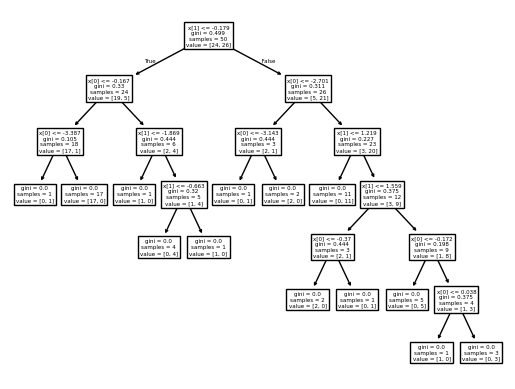

In [26]:
plot_tree(clf1)

[Text(0.5, 0.9285714285714286, 'x[1] <= -0.303\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.25, 0.7857142857142857, 'x[1] <= -2.572\ngini = 0.087\nsamples = 22\nvalue = [21, 1]'),
 Text(0.375, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.6428571428571429, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.75, 0.7857142857142857, 'x[1] <= 1.234\ngini = 0.293\nsamples = 28\nvalue = [5, 23]'),
 Text(0.625, 0.8571428571428572, '  False'),
 Text(0.625, 0.6428571428571429, 'x[0] <= -1.76\ngini = 0.459\nsamples = 14\nvalue = [5, 9]'),
 Text(0.5, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.5, 'x[1] <= 1.086\ngini = 0.375\nsamples = 12\nvalue = [3, 9]'),
 Text(0.625, 0.35714285714285715, 'x[1] <= -0.084\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.5, 0.21428571428571427, 'x[0] <= -1.091\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.375, 0.07142857142857142, 'gini = 0.

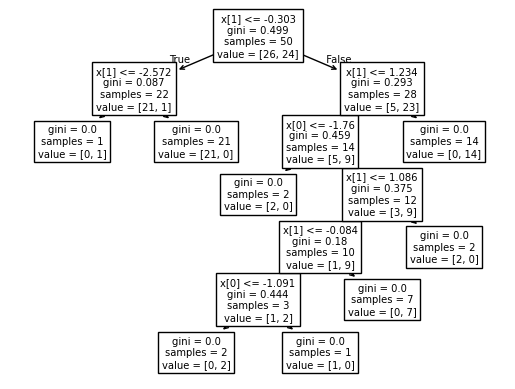

In [27]:
plot_tree(clf2)

[Text(0.5769230769230769, 0.9, 'x[1] <= -0.308\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.3076923076923077, 0.7, 'x[0] <= 1.602\ngini = 0.302\nsamples = 27\nvalue = [22, 5]'),
 Text(0.4423076923076923, 0.8, 'True  '),
 Text(0.15384615384615385, 0.5, 'x[1] <= -0.469\ngini = 0.095\nsamples = 20\nvalue = [19, 1]'),
 Text(0.07692307692307693, 0.3, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.23076923076923078, 0.3, 'x[1] <= -0.377\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.15384615384615385, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3076923076923077, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.46153846153846156, 0.5, 'x[0] <= 2.211\ngini = 0.49\nsamples = 7\nvalue = [3, 4]'),
 Text(0.38461538461538464, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.5384615384615384, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8461538461538461, 0.7, 'x[0] <= -0.5\ngini = 0.159\nsamples = 23\nvalue = [2, 21]'),
 Text(0.71153

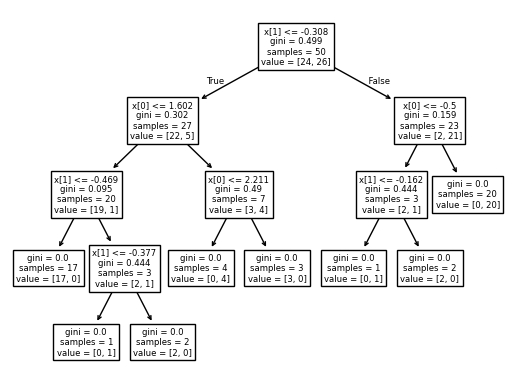

In [28]:
plot_tree(clf3)

In [29]:
clf1.predict(np.array([-1.32453, -0.32412]).reshape(1,2))

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [30]:
clf2.predict(np.array([-1.54653, 0.234235]).reshape(1,2))

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [34]:
clf2.predict(np.array([-0.653, 1.4235]).reshape(1,2))

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [45]:
df.sample(12,replace = True)

,col1,col2,col3,col4,col5,target
20,0.662443,0.338807,-0.942204,-2.676909,1.956847,1
13,-1.433384,-0.232402,-1.359704,-1.490396,-0.977399,1
36,1.213925,-1.522456,-1.607634,1.841757,-2.687534,1
80,3.247423,-0.317315,-2.592023,0.614953,0.758414,1
82,-1.955698,-1.268246,-0.516052,-1.705219,0.401092,0
56,0.659190,-2.682829,-0.968312,1.038956,-1.125085,1
69,0.034749,-1.480074,-0.705675,-0.518768,-0.504306,0
56,0.659190,-2.682829,-0.968312,1.038956,-1.125085,1
92,0.547855,0.786773,1.465643,0.685964,-1.817680,1
35,-0.651816,-1.375122,-0.176010,-0.761196,0.059505,0
